In [5]:
import torch
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

True
Tesla T4


In [6]:
!pip install kaggle

!mkdir -p KGAT_f78cf5b36dec0da3b05142ff25ad1055/.kaggle/
!cp kaggle.json KGAT_f78cf5b36dec0da3b05142ff25ad1055/.kaggle/
!chmod 600 KGAT_f78cf5b36dec0da3b05142ff25ad1055/.kaggle/kaggle.json

cp: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access 'KGAT_f78cf5b36dec0da3b05142ff25ad1055/.kaggle/kaggle.json': No such file or directory


In [7]:
!kaggle datasets download -d paultimothymooney/chest-xray-pneumonia
!unzip -q chest-xray-pneumonia.zip

Dataset URL: https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia
License(s): other
100% 2.29G/2.29G [00:30<00:00, 80.1MB/s]



In [12]:
from torchvision import datasets, transforms

train_dir = "/content/chest_xray/train"

basic_tf = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

train_ds = datasets.ImageFolder(train_dir, transform=basic_tf)

print(train_ds.classes)
print(train_ds.class_to_idx)
print(len(train_ds))

['NORMAL', 'PNEUMONIA']
{'NORMAL': 0, 'PNEUMONIA': 1}
5216


In [13]:
from torch.utils.data import DataLoader

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)

images, labels = next(iter(train_loader))
print(images.shape)
print(labels.shape)

torch.Size([32, 3, 224, 224])
torch.Size([32])


In [14]:
from torchvision import datasets, transforms

basic_tf = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

train_ds = datasets.ImageFolder(train_dir, transform=basic_tf)

print(train_ds.classes)
print(train_ds.class_to_idx)
print(len(train_ds))

['NORMAL', 'PNEUMONIA']
{'NORMAL': 0, 'PNEUMONIA': 1}
5216


torch.Size([3, 224, 224]) label: 0 NORMAL


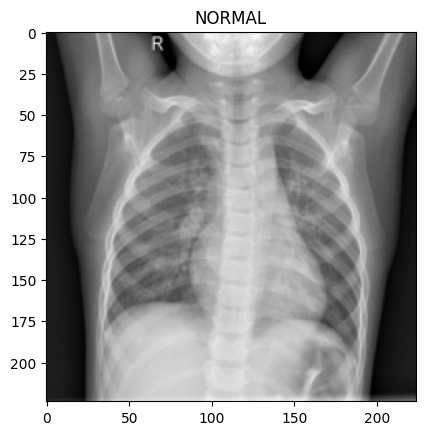

In [20]:
import matplotlib.pyplot as plt

img, label = train_ds[0]
print(img.shape, 'label:', label, train_ds.classes[label])

plt.imshow(img.permute(1, 2, 0))
plt.title(train_ds.classes[label])
plt.show()

torch.Size([3, 224, 224]) label: 1 PNEUMONIA


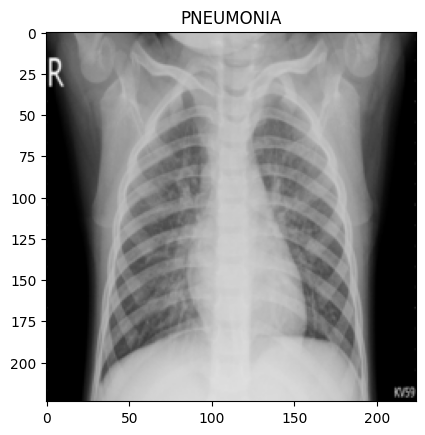

In [27]:
import matplotlib.pyplot as plt

img, label = train_ds[4000]
print(img.shape, 'label:', label, train_ds.classes[label])

plt.imshow(img.permute(1, 2, 0))
plt.title(train_ds.classes[label])
plt.show()

In [26]:
import numpy as np

targets = np.array(train_ds.targets)
n_normal = (targets == 0).sum()
n_pneumonia = (targets == 1).sum()
print("NORMAL:", n_normal, "PNEUMONIA:", n_pneumonia)
print("ratio(pneu/norm):", n_pneumonia / n_normal)

NORMAL: 1341 PNEUMONIA: 3875
ratio(pneu/norm): 2.889634601043997
